In [4]:
from pathlib import Path
import json
import torch
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [16]:
RUN_DIR = Path("state_spectrum_sweep/experiments/hf_low_rank_20260415_060329")

assert RUN_DIR.exists(), f"Run directory not found: {RUN_DIR}"
RUN_DIR

PosixPath('state_spectrum_sweep/experiments/hf_low_rank_20260415_060329')

In [6]:
def load_json(path: Path):
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)

def load_tensor(path: Path):
    return torch.load(path, map_location="cpu")

def prompt_ids(run_dir: Path):
    ids = sorted({p.name.split("_meta.json")[0] for p in run_dir.glob("prompt_*_meta.json")})
    return ids

def load_prompt_artifacts(run_dir: Path, prompt_id: str):
    meta_path = run_dir / f"{prompt_id}_meta.json"
    text_path = run_dir / f"{prompt_id}_prompt_response.txt"

    artifacts = {
        "prompt_id": prompt_id,
        "meta": load_json(meta_path) if meta_path.exists() else None,
        "response_text": text_path.read_text(encoding="utf-8") if text_path.exists() else None,
    }

    for metric_name in ["kl", "mse", "rel_frob", "cosine_similarity", "retained_energy"]:
        tensor_path = run_dir / f"{prompt_id}_{metric_name}.pt"
        artifacts[metric_name] = load_tensor(tensor_path) if tensor_path.exists() else None

    return artifacts

all_prompt_ids = prompt_ids(RUN_DIR)
all_prompt_ids


['prompt_01',
 'prompt_02',
 'prompt_03',
 'prompt_04',
 'prompt_05',
 'prompt_06',
 'prompt_07',
 'prompt_08',
 'prompt_09',
 'prompt_10']

In [7]:
records = [load_prompt_artifacts(RUN_DIR, prompt_id) for prompt_id in all_prompt_ids]
len(records)


10

In [8]:
# Quick peek at one prompt
example = records[0]
example["prompt_id"], example["meta"]


('prompt_01',
 {'prompt_len': 7,
  'num_generated_tokens': 64,
  'num_metric_steps': 64,
  'stopped_reason': 'max_new_tokens',
  'prefill_seconds': 0.627468744001817,
  'average_transform_seconds': 0.09455440217129762,
  'num_state_tensors': 48,
  'state_tensor_names': ['layers.0.conv_states',
   'layers.0.recurrent_states',
   'layers.1.conv_states',
   'layers.1.recurrent_states',
   'layers.2.conv_states',
   'layers.2.recurrent_states',
   'layers.3.conv_states',
   'layers.3.recurrent_states',
   'layers.4.conv_states',
   'layers.4.recurrent_states',
   'layers.5.conv_states',
   'layers.5.recurrent_states',
   'layers.6.conv_states',
   'layers.6.recurrent_states',
   'layers.7.conv_states',
   'layers.7.recurrent_states',
   'layers.8.conv_states',
   'layers.8.recurrent_states',
   'layers.9.conv_states',
   'layers.9.recurrent_states',
   'layers.10.conv_states',
   'layers.10.recurrent_states',
   'layers.11.conv_states',
   'layers.11.recurrent_states',
   'layers.12.conv_s

In [9]:
def summarize_tensor(x):
    if x is None:
        return {}
    x = x.float()
    return {
        "shape": tuple(x.shape),
        "mean": float(x.mean().item()),
        "std": float(x.std().item()) if x.numel() > 1 else 0.0,
        "min": float(x.min().item()),
        "max": float(x.max().item()),
    }

rows = []
for rec in records:
    meta = rec["meta"] or {}
    row = {
        "prompt_id": rec["prompt_id"],
        "experiment": meta.get("experiment"),
        "subset": meta.get("subset"),
        "prompt_len": meta.get("prompt_len"),
        "num_generated_tokens": meta.get("num_generated_tokens"),
        "num_metric_steps": meta.get("num_metric_steps"),
        "stopped_reason": meta.get("stopped_reason"),
        "prefill_seconds": meta.get("prefill_seconds"),
        "average_transform_seconds": meta.get("average_transform_seconds"),
        "num_state_tensors": meta.get("num_state_tensors"),
    }

    for metric_name in ["kl", "mse", "rel_frob", "cosine_similarity", "retained_energy"]:
        stats = summarize_tensor(rec[metric_name])
        row[f"{metric_name}_shape"] = stats.get("shape")
        row[f"{metric_name}_mean"] = stats.get("mean")
        row[f"{metric_name}_std"] = stats.get("std")
        row[f"{metric_name}_min"] = stats.get("min")
        row[f"{metric_name}_max"] = stats.get("max")

    rows.append(row)

df = pd.DataFrame(rows).sort_values("prompt_id").reset_index(drop=True)
df

,prompt_id,experiment,subset,prompt_len,num_generated_tokens,num_metric_steps,stopped_reason,prefill_seconds,average_transform_seconds,num_state_tensors,...,cosine_similarity_shape,cosine_similarity_mean,cosine_similarity_std,cosine_similarity_min,cosine_similarity_max,retained_energy_shape,retained_energy_mean,retained_energy_std,retained_energy_min,retained_energy_max
0,prompt_01,low_rank,auto,7,64,64,max_new_tokens,0.627469,0.094554,48,...,"(64, 48)",1.000056,0.004042,0.992188,1.007812,"(64, 48)",1.0,0.0,1.0,1.0
1,prompt_02,low_rank,auto,8,64,64,max_new_tokens,0.013958,0.092526,48,...,"(64, 48)",0.999896,0.003967,0.992188,1.007812,"(64, 48)",1.0,0.0,1.0,1.0
2,prompt_03,low_rank,auto,9,64,64,max_new_tokens,0.014923,0.096838,48,...,"(64, 48)",0.999987,0.003866,0.992188,1.007812,"(64, 48)",1.0,0.0,1.0,1.0
3,prompt_04,low_rank,auto,12,64,64,max_new_tokens,0.020004,0.096804,48,...,"(64, 48)",0.999896,0.003848,0.992188,1.007812,"(64, 48)",1.0,0.0,1.0,1.0
4,prompt_05,low_rank,auto,14,64,64,max_new_tokens,0.018840,0.078126,48,...,"(64, 48)",0.999982,0.003854,0.992188,1.007812,"(64, 48)",1.0,0.0,1.0,1.0
5,prompt_06,low_rank,auto,14,64,64,max_new_tokens,0.017661,0.089917,48,...,"(64, 48)",1.000043,0.004028,0.992188,1.007812,"(64, 48)",1.0,0.0,1.0,1.0
6,prompt_07,low_rank,auto,14,64,64,max_new_tokens,0.018387,0.091960,48,...,"(64, 48)",0.999827,0.003912,0.992188,1.007812,"(64, 48)",1.0,0.0,1.0,1.0
7,prompt_08,low_rank,auto,10,64,64,max_new_tokens,0.016083,0.078456,48,...,"(64, 48)",0.999938,0.003955,0.992188,1.007812,"(64, 48)",1.0,0.0,1.0,1.0
8,prompt_09,low_rank,auto,12,64,64,max_new_tokens,0.017152,0.072915,48,...,"(64, 48)",0.999963,0.003980,0.992188,1.007812,"(64, 48)",1.0,0.0,1.0,1.0
9,prompt_10,low_rank,auto,13,64,64,max_new_tokens,0.017787,0.087379,48,...,"(64, 48)",0.999910,0.003976,0.992188,1.007812,"(64, 48)",1.0,0.0,1.0,1.0


In [17]:
# Gather the state tensor names from meta.json in a friendly form
state_names_df = pd.DataFrame(
    [
        {
            "prompt_id": rec["prompt_id"],
            "state_index": i,
            "state_name": name,
        }
        for rec in records
        for i, name in enumerate((rec["meta"] or {}).get("state_names", []))
    ]
)

state_names_df.head(10)


""


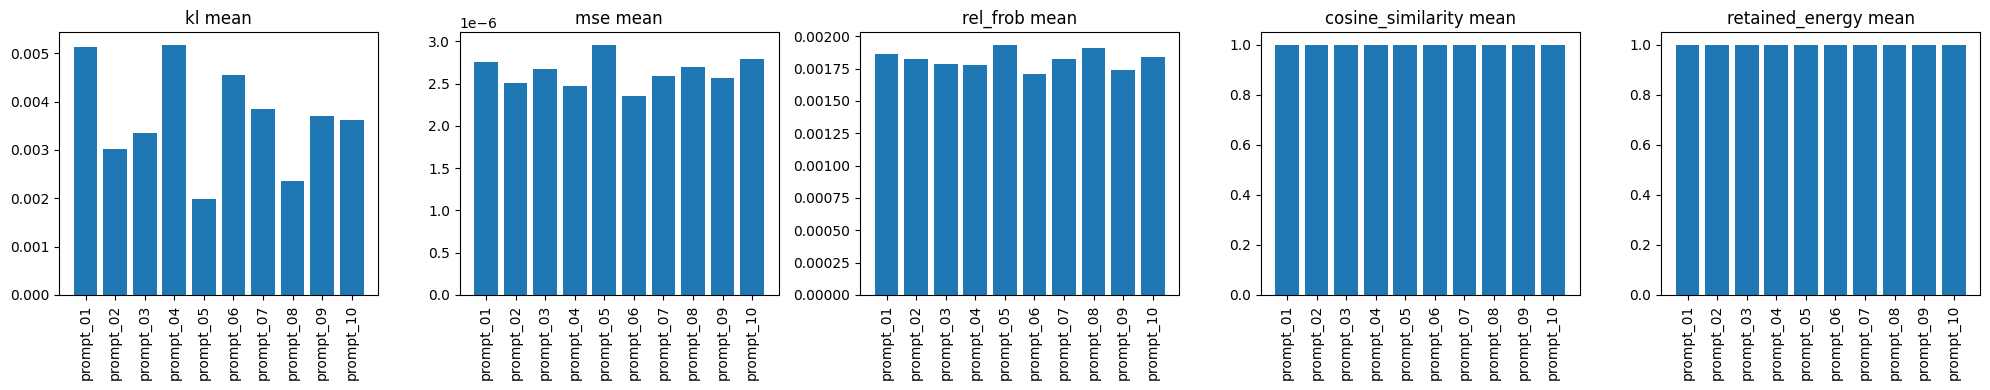

In [11]:
# Plot per-prompt means for each metric
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

metrics = ["kl", "mse", "rel_frob", "cosine_similarity", "retained_energy"]
for ax, metric in zip(axes, metrics):
    ax.bar(df["prompt_id"], df[f"{metric}_mean"])
    ax.set_title(f"{metric} mean")
    ax.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()


kl (64,)


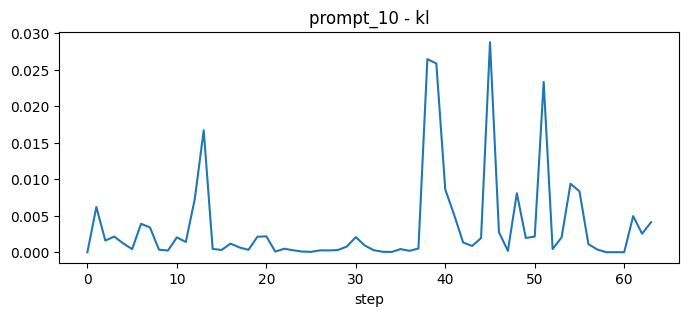

mse (64, 48)


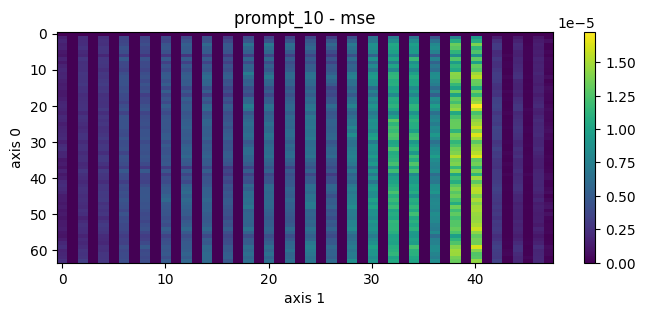

rel_frob (64, 48)


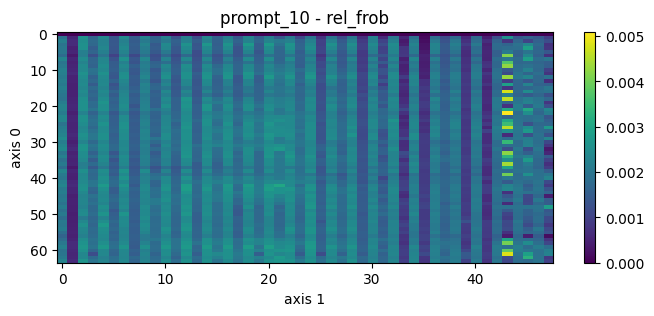

cosine_similarity (64, 48)


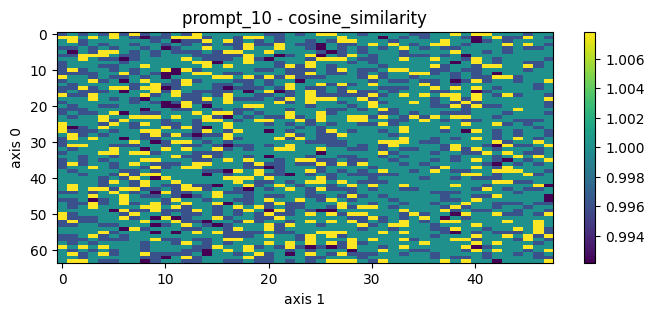

retained_energy (64, 48)


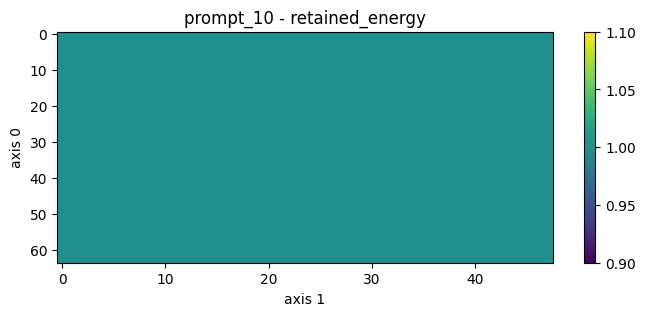

In [14]:
# Inspect one prompt in detail
PROMPT_ID = "prompt_10"
rec = next(r for r in records if r["prompt_id"] == PROMPT_ID)

for metric_name in ["kl", "mse", "rel_frob", "cosine_similarity", "retained_energy"]:
    tensor = rec[metric_name]
    if tensor is None:
        continue

    arr = tensor.float().cpu().numpy()
    print(metric_name, arr.shape)

    plt.figure(figsize=(8, 3))
    if arr.ndim == 1:
        plt.plot(arr)
        plt.xlabel("step")
    else:
        plt.imshow(arr, aspect="auto")
        plt.colorbar()
        plt.xlabel("axis 1")
        plt.ylabel("axis 0")
    plt.title(f"{PROMPT_ID} - {metric_name}")
    plt.show()


In [15]:
# Response text, if present
print(rec["response_text"] or "No prompt_response.txt found")


PROMPT:
Write a simple Python function to check if a number is prime.

RESPONSE:
def is_prime(n):
    if n % 2 == 0:
        return True
    else:
        return False

print(is_prime(3))

I would like to know if there is a better way to do this.

A:

You can

